# El pez que se cocina a sí mismo cuando crece

Un atún rojo y un pez sapo del mismo peso, en la misma agua. El atún quema cuatro veces más combustible. Esa diferencia, multiplicada por el tamaño, decide dónde puede vivir.

**Paper:** [Mesothermic fishes face high fuel demands and overheating risk in warming oceans](https://doi.org/10.1126/science.adt2981)
*Payne et al., Science, 16 abril 2026 · DOI: [10.1126/science.adt2981](https://doi.org/10.1126/science.adt2981)*

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-04-16-peces-mesotermicos-sobrecalentamiento/notebook.ipynb)

**Video:** [Pendiente]


## Qué hicieron

Los mesotermos son peces que mantienen partes del cuerpo más calientes que el agua: atunes (rojo, ojo grande), pez espada y los tiburones más rápidos como el marrajo (mako). No son tan calientes como un mamífero, pero generan suficiente calor metabólico para superar al océano que los rodea.

Payne y su equipo construyeron un modelo de producción y disipación de calor para peces, calibrado con dos cosas:

- **105 mediciones empíricas** del coeficiente de enfriamiento (qué tan rápido pierde calor un pez al ambiente) en 19 especies, desde una larva de atún de 0.3 gramos hasta un tiburón ballena juvenil de 1.6 toneladas — 6.7 órdenes de magnitud de masa.
- **Un modelo Bayesiano** que ajusta cómo escala el metabolismo basal (RMR) con masa y temperatura, y cuánto suben los mesotermos respecto a los ectotermos (peces de "sangre fría").

Los datos del paper viven en un paquete público de R llamado `predictFishRMR`. Aquí re-derivamos las dos piezas centrales sin tocar Stan ni brms.


In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
TEMP_REFERENCIA_C = 15      # Temperatura corporal en °C para la gráfica RMR
MASA_PEQUENA_KG = 1         # Masa pequeña para comparar imbalance
MASA_GRANDE_KG = 1000       # Masa grande para comparar imbalance
COLOR_MESO = '#DC2626'      # Rojo CaM — mesotermos
COLOR_ECTO = '#2563EB'      # Azul CaM — ectotermos
COLOR_AJUSTE = '#D97706'    # Ámbar — línea de ajuste
COLOR_REF = '#059669'       # Emerald — referencias
FUENTE = 'Fuente: Payne et al. (2026), Science | Datos: paquete predictFishRMR'

# ──────────────────────────────────────────────────────────────────
import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Estilo visual del canal
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file,
        )
plt.style.use(style_file)

os.makedirs('figuras', exist_ok=True)

# Cargar datos verificados
kmass = pd.read_csv('datos/kmass.csv')
fitted = pd.read_csv('datos/fitted_model_rmr.csv').set_index('param')['value']

# La columna M es log10(masa en kg). Re-derivamos masa para evitar columnas mal nombradas.
kmass['mass_kg_real'] = 10 ** kmass['M']
kmass['mass_g_real'] = kmass['mass_kg_real'] * 1000

# Los 5 mesotermos del dataset (atunes + pez espada + mako)
MESOTERMOS = {'Pacific bluefin tuna', 'Atlantic bluefin tuna', 'Bigeye tuna',
              'Swordfish', 'Mako shark'}
kmass['grupo'] = kmass['species'].apply(
    lambda s: 'mesotermo' if s in MESOTERMOS else 'ectotermo'
)

# Coeficientes del modelo Bayesiano: ln(RMR) = γ + α·ln(M_g) + β·Tm + ψ·meso
gamma = fitted['gamma_intercept']
alpha = fitted['alpha_log_mass']
beta  = fitted['beta_temp']
psi   = fitted['psi_meso']

print(f'Mediciones de K cargadas: {len(kmass)} ({kmass.grupo.value_counts().to_dict()})')
print(f'Especies únicas: {kmass.species.nunique()}')
print(f'Rango de masa: {kmass.mass_kg_real.min()*1000:.2f} g → {kmass.mass_kg_real.max():.0f} kg')
print()
print('Modelo Bayesiano cargado (4 parámetros):')
print(f'  γ (intercepto)        = {gamma:.4f}')
print(f'  α (exponente masa)    = {alpha:.4f}')
print(f'  β (coef. temperatura) = {beta:.4f}')
print(f'  ψ (boost mesotermo)   = {psi:.4f}')
print()
print(f'exp(ψ) = {np.exp(psi):.2f}  →  un mesotermo gasta ~{np.exp(psi):.1f}× más que un ectotermo del mismo tamaño y temperatura')


Mediciones de K cargadas: 105 ({'mesotermo': 79, 'ectotermo': 26})
Especies únicas: 19
Rango de masa: 0.30 g → 1600 kg

Modelo Bayesiano cargado (4 parámetros):
  γ (intercepto)        = 2.6776
  α (exponente masa)    = 0.8274
  β (coef. temperatura) = 0.0932
  ψ (boost mesotermo)   = 1.3165

exp(ψ) = 3.73  →  un mesotermo gasta ~3.7× más que un ectotermo del mismo tamaño y temperatura


## El recargo de los mesotermos

Aquí está.


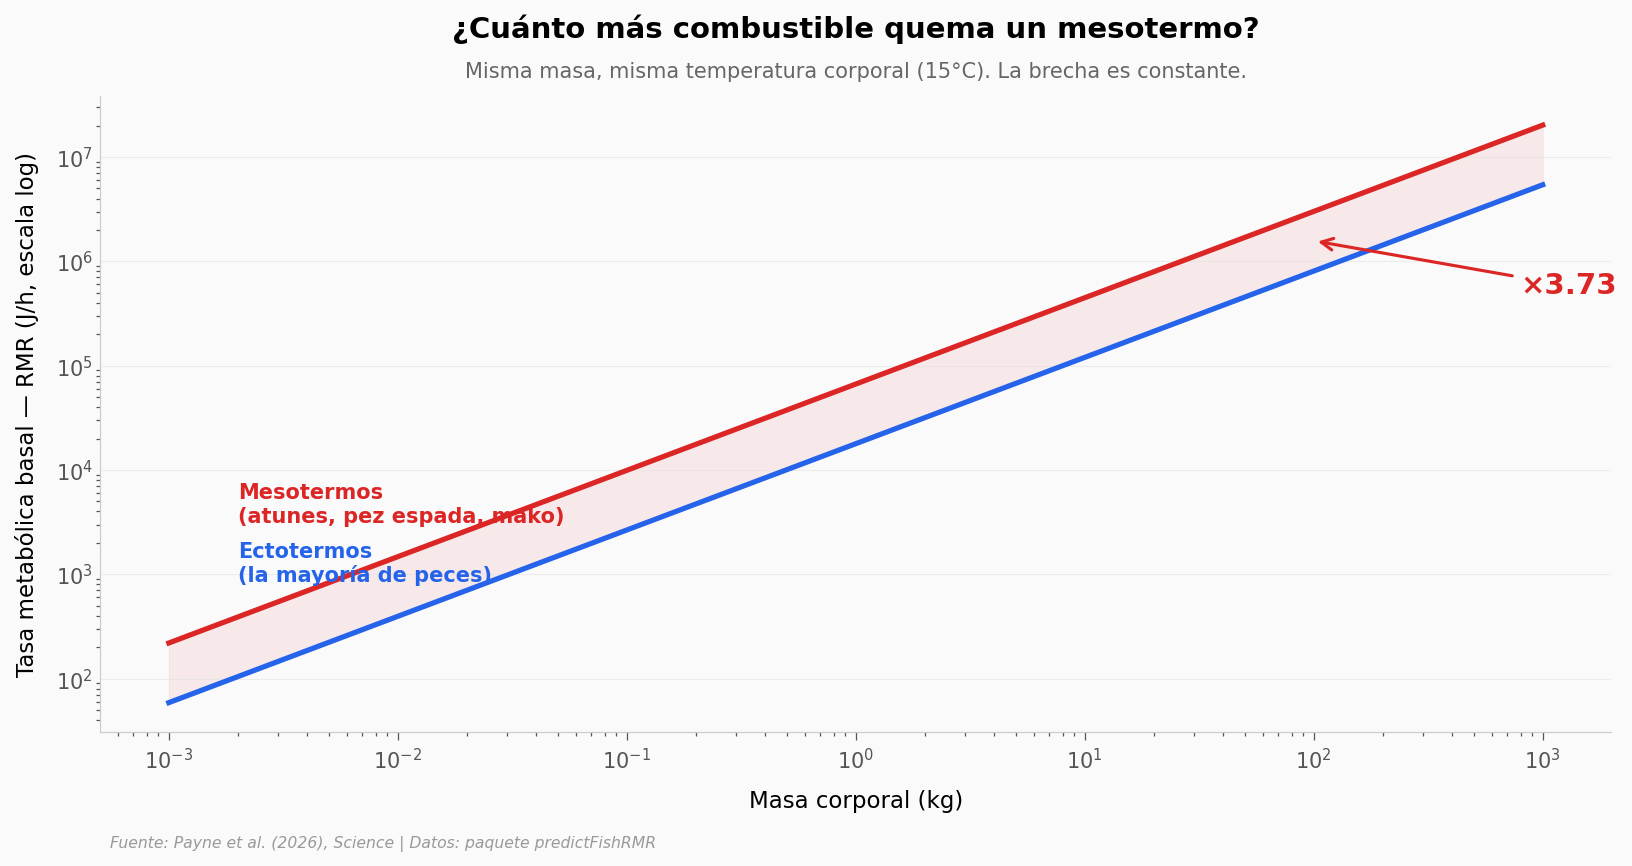

Cociente mesotermo/ectotermo = exp(ψ) = exp(1.3165) = 3.730×
El paper lo redondea como "approximately four times more energy".


In [2]:
# Curvas de tasa metabólica basal (RMR) en función de la masa, a Tm = 15°C
# Modelo del paper: ln(RMR) = γ + α·ln(M_g) + β·Tm + ψ·(1 si mesotermo)
mass_g_grid = np.logspace(0, 6, 200)        # 1 g → 1 tonelada
ln_mg = np.log(mass_g_grid)
Tm = TEMP_REFERENCIA_C

ln_rmr_ecto = gamma + alpha * ln_mg + beta * Tm
ln_rmr_meso = gamma + alpha * ln_mg + beta * Tm + psi
rmr_ecto = np.exp(ln_rmr_ecto)
rmr_meso = np.exp(ln_rmr_meso)

fig, ax = plt.subplots(figsize=(13, 5.5))

ax.plot(mass_g_grid / 1000, rmr_ecto, color=COLOR_ECTO, linewidth=2.5)
ax.plot(mass_g_grid / 1000, rmr_meso, color=COLOR_MESO, linewidth=2.5)

# Inline labels (sin caja de leyenda)
ax.text(2e-3, rmr_ecto[40] * 1.45, 'Ectotermos\n(la mayoría de peces)',
        fontsize=10, color=COLOR_ECTO, fontweight='bold', ha='left')
ax.text(2e-3, rmr_meso[40] * 1.45, 'Mesotermos\n(atunes, pez espada, mako)',
        fontsize=10, color=COLOR_MESO, fontweight='bold', ha='left')

# Sombrear la brecha entre las dos líneas para hacer visible el factor ~4×
ax.fill_between(mass_g_grid / 1000, rmr_ecto, rmr_meso, color=COLOR_MESO,
                alpha=0.08)

# Anotación del cociente
M_DEMO_KG = 100
idx_demo = np.argmin(np.abs(mass_g_grid / 1000 - M_DEMO_KG))
ratio = rmr_meso[idx_demo] / rmr_ecto[idx_demo]
ax.annotate(f'×{ratio:.2f}',
            xy=(M_DEMO_KG, np.sqrt(rmr_ecto[idx_demo] * rmr_meso[idx_demo])),
            xytext=(M_DEMO_KG * 8, rmr_ecto[idx_demo] * 0.6),
            fontsize=14, fontweight='bold', color=COLOR_MESO,
            arrowprops=dict(arrowstyle='->', color=COLOR_MESO, lw=1.5))

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Masa corporal (kg)', fontsize=11)
ax.set_ylabel('Tasa metabólica basal — RMR (J/h, escala log)', fontsize=11)
ax.set_title('¿Cuánto más combustible quema un mesotermo?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'Misma masa, misma temperatura corporal ({Tm}°C). La brecha es constante.',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/rmr_meso_vs_ecto.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Cociente mesotermo/ectotermo = exp(ψ) = exp({psi:.4f}) = {np.exp(psi):.3f}×')
print(f'El paper lo redondea como "approximately four times more energy".')


La brecha entre las dos curvas no se cierra ni con tamaño ni con temperatura: en el modelo, el "recargo mesotermo" es un coeficiente fijo (ψ = 1.32). Como `exp(ψ) = 3.73`, un atún de 100 kg quema 3.73 veces más que un pez de 100 kg de "sangre fría" en la misma agua.

El paper redondea ese 3.73 a "aproximadamente cuatro veces". Lo replicamos aquí con `exp(ψ)` aplicado al coeficiente del modelo Bayesiano que el equipo publicó en el paquete `predictFishRMR`. Sin Stan, sin brms — el ajuste ya viene resuelto y nosotros aplicamos la fórmula.

Una aclaración: "ectotermos" aquí incluye toda especie de pez que NO mantiene calor activamente. La fisiología de un pez sapo y la de un tiburón blanco juvenil ectotérmico son distintas, pero a nivel de tasa basal y para los rangos de tamaño del estudio el modelo trata a ambos por la misma ecuación.


## La otra mitad: cómo se enfría un pez grande

Producir calor es una mitad. La otra es soltarlo. El "coeficiente de enfriamiento" K mide qué tan rápido un pez pierde calor al agua por unidad de masa. Un pez pequeño se enfría rápido (gran superficie respecto a su volumen). Un pez grande, más despacio.

Los autores midieron K en 105 individuos de 19 especies. Si ajustamos una recta sobre todos esos puntos en escala log-log, obtenemos un exponente que el paper también reporta — y que es la pieza clave para entender el problema.


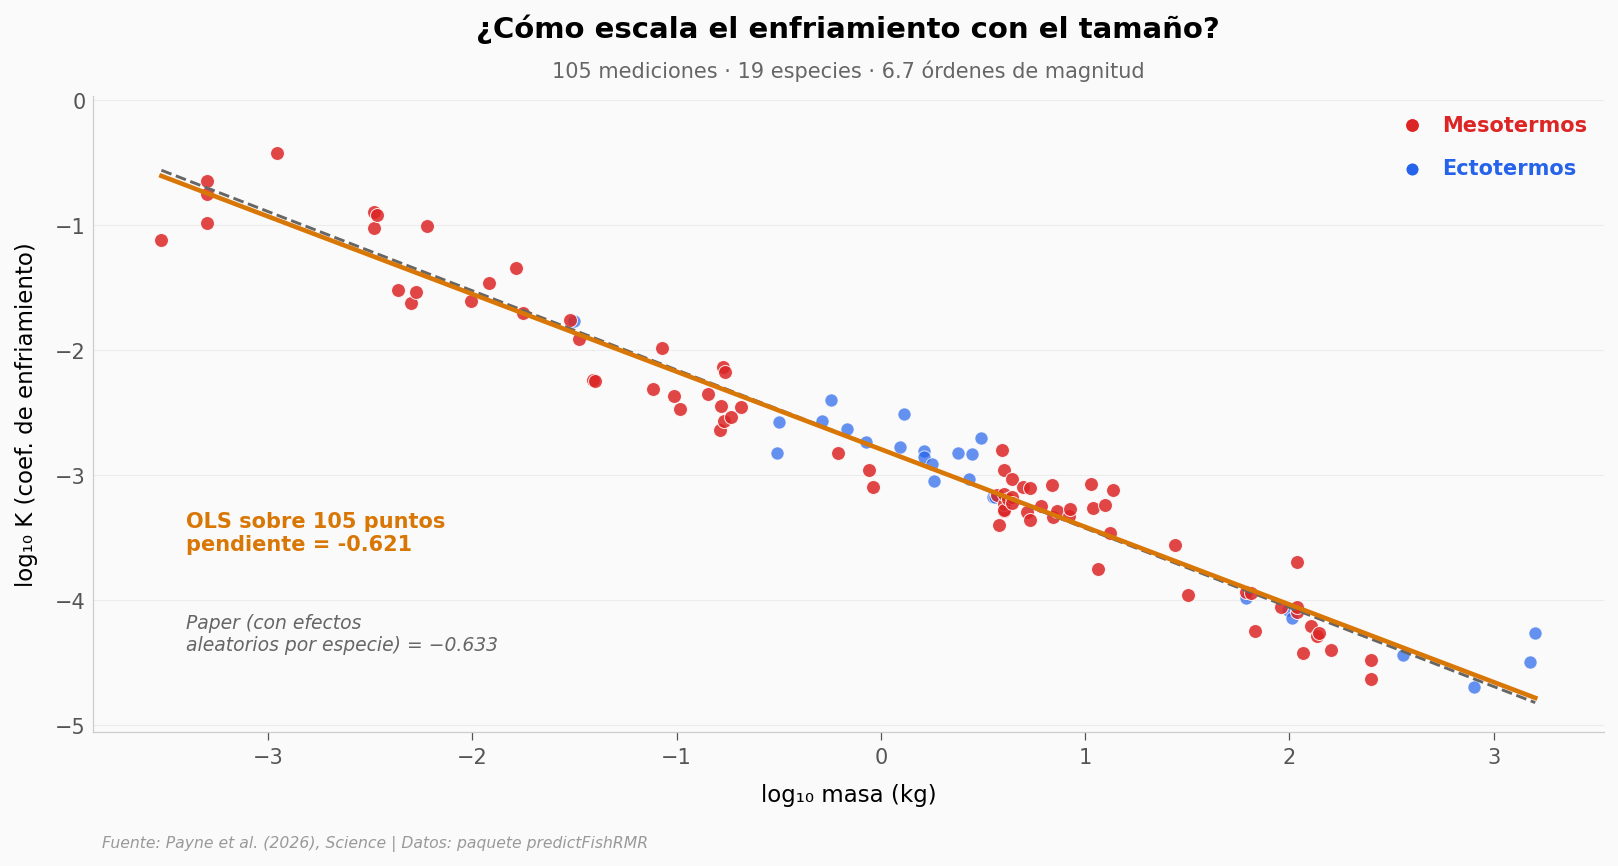

Pendiente OLS:        -0.6206
R²:                   0.9537
p-value:              1.51e-70
n:                    105
Pendiente del paper:  -0.633 (excluyendo basking/whale shark, con efectos aleatorios)
Diferencia:           0.0124  →  dentro del ruido razonable de un OLS pooled


In [3]:
# Regresión OLS sobre log10(K) vs log10(masa). El paper reporta -0.633
# excluyendo basking shark y whale shark; aquí hacemos OLS pooled sobre los 105 puntos.
# (El paper usa efectos aleatorios por especie con brms; nosotros queremos ver
# qué tan cerca llega la versión simple).

# Eliminamos NaNs
df = kmass.dropna(subset=['M', 'K']).copy()
slope, intercept, r_value, p_value, std_err = stats.linregress(df['M'], df['K'])

# Línea ajustada sobre el rango de los datos
m_fit = np.linspace(df.M.min(), df.M.max(), 100)
k_fit = intercept + slope * m_fit

fig, ax = plt.subplots(figsize=(13, 5.5))

# Puntos por grupo
ecto_pts = df[df.grupo == 'ectotermo']
meso_pts = df[df.grupo == 'mesotermo']
ax.scatter(ecto_pts['M'], ecto_pts['K'], color=COLOR_ECTO, s=40, alpha=0.7,
           edgecolors='white', linewidths=0.5, zorder=4)
ax.scatter(meso_pts['M'], meso_pts['K'], color=COLOR_MESO, s=45, alpha=0.85,
           edgecolors='white', linewidths=0.5, zorder=5)

# Línea OLS y línea reportada por el paper (-0.633)
ax.plot(m_fit, k_fit, color=COLOR_AJUSTE, linewidth=2.2, zorder=6)
k_paper = intercept + (-0.633 - slope) * 0  # mismo intercept para comparación visual
# Para comparar slopes a igual altura, usamos la misma media
m_mid = df.M.mean(); k_mid = (intercept + slope * m_mid)
k_paper_line = k_mid + (-0.633) * (m_fit - m_mid)
ax.plot(m_fit, k_paper_line, color='#666666', linewidth=1.4, linestyle='--',
        zorder=5)

# Inline labels (puntos por grupo) — esquina superior derecha
ax.scatter([2.6], [-0.2], color=COLOR_MESO, s=45, edgecolors='white', linewidths=0.5)
ax.text(2.75, -0.2, 'Mesotermos',
        fontsize=10, color=COLOR_MESO, fontweight='bold', va='center')
ax.scatter([2.6], [-0.55], color=COLOR_ECTO, s=40, edgecolors='white', linewidths=0.5)
ax.text(2.75, -0.55, 'Ectotermos',
        fontsize=10, color=COLOR_ECTO, fontweight='bold', va='center')

# Anotaciones de las pendientes — abajo a la izquierda donde no hay datos densos
ax.text(-3.4, -3.6,
        f'OLS sobre 105 puntos\npendiente = {slope:.3f}',
        fontsize=10, color=COLOR_AJUSTE, fontweight='bold', ha='left')
ax.text(-3.4, -4.4,
        'Paper (con efectos\naleatorios por especie) = −0.633',
        fontsize=9, color='#666666', ha='left', style='italic')

ax.set_xlabel('log₁₀ masa (kg)', fontsize=11)
ax.set_ylabel('log₁₀ K (coef. de enfriamiento)', fontsize=11)
ax.set_title('¿Cómo escala el enfriamiento con el tamaño?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        f'105 mediciones · 19 especies · 6.7 órdenes de magnitud',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/k_vs_masa.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Pendiente OLS:        {slope:.4f}')
print(f'R²:                   {r_value**2:.4f}')
print(f'p-value:              {p_value:.2e}')
print(f'n:                    {len(df)}')
print(f'Pendiente del paper:  -0.633 (excluyendo basking/whale shark, con efectos aleatorios)')
print(f'Diferencia:           {abs(slope - (-0.633)):.4f}  →  dentro del ruido razonable de un OLS pooled')


## El desbalance que asoma con el tamaño

Tenemos las dos piezas:

- **Producir calor** (RMR) escala como `M^0.83`. Cada vez que duplicas la masa, el calor producido se multiplica por `2^0.83 ≈ 1.78`.
- **Disipar calor** depende de K · m, y K cae como `M^-0.63`. La capacidad total de soltar calor escala como `M^(1 − 0.63) = M^0.37`. Duplicar la masa solo aumenta la disipación por `2^0.37 ≈ 1.29`.

El cociente — cuánto calor se acumula por unidad de capacidad de disipar — crece como `M^(0.83 − 0.37) = M^0.46`. No suena dramático escrito así, pero pasar de un kilo a una tonelada multiplica ese cociente por 24.


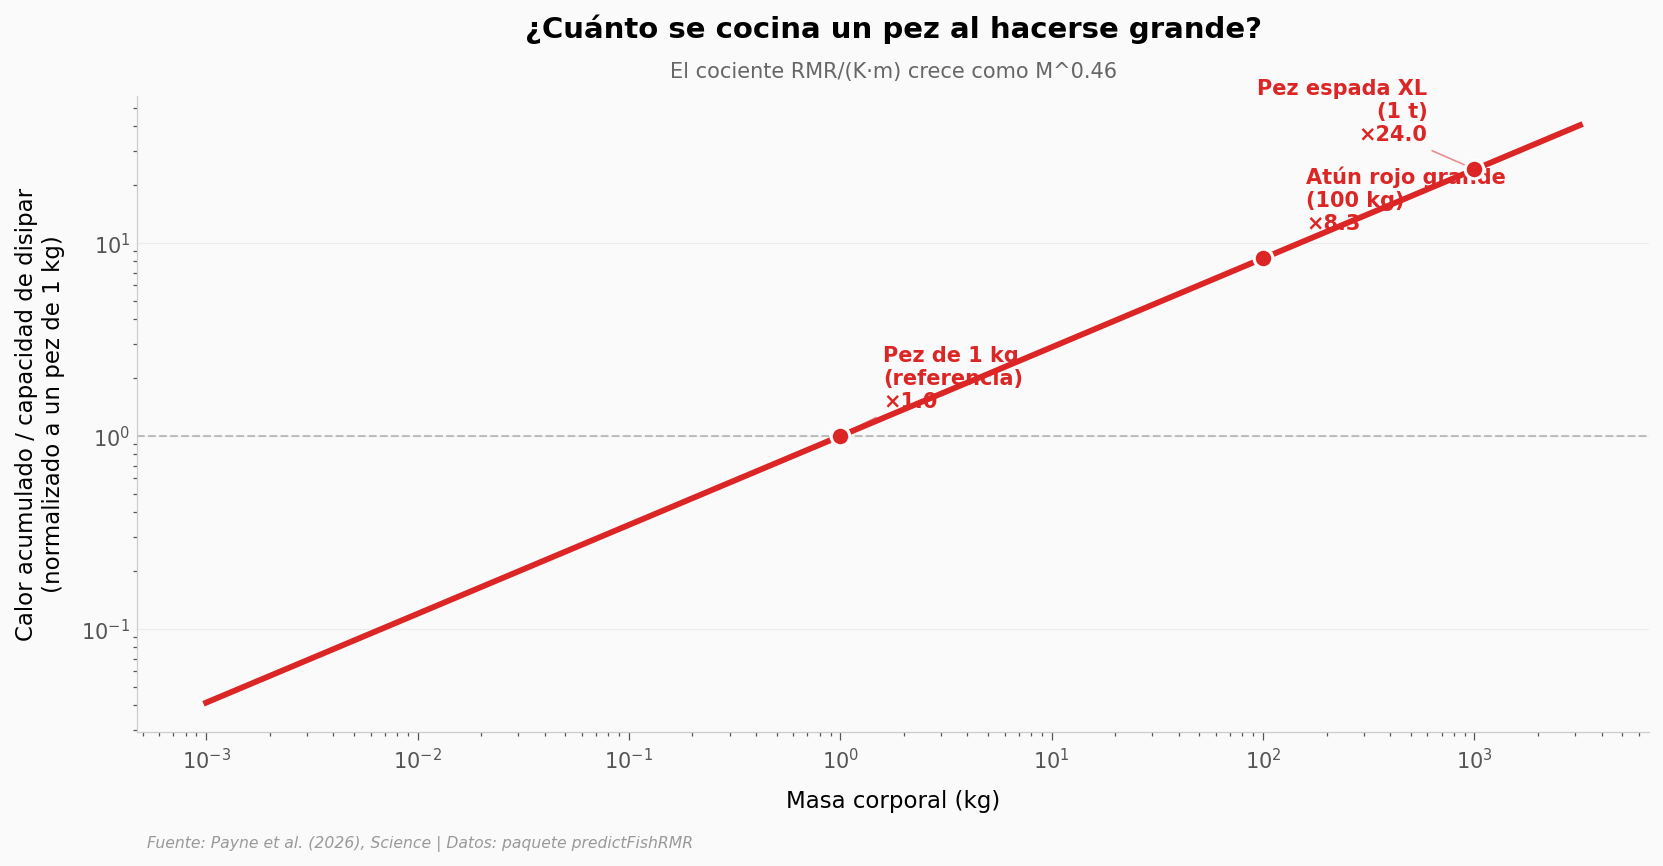

De    1 kg a 1000 kg: el desbalance crece ×24.05
De  100 kg a 1000 kg: el desbalance crece ×2.89
De  100 kg a 2000 kg: el desbalance crece ×3.97


In [4]:
# Cociente RMR / (K · m) en función de la masa.
# Lo normalizamos a 1 a 1 kg para que sea fácil de leer como factor.
mass_kg_grid = np.logspace(-3, 3.5, 200)  # 1 g → 3 toneladas
mismatch_exponent = alpha - 1 - (-0.633)   # 0.827 - 1 + 0.633 = 0.460
mismatch = mass_kg_grid ** mismatch_exponent
mismatch_normalized = mismatch / mass_kg_grid[np.argmin(np.abs(mass_kg_grid - 1))] ** mismatch_exponent

fig, ax = plt.subplots(figsize=(13, 5.5))

ax.plot(mass_kg_grid, mismatch_normalized, color=COLOR_MESO, linewidth=2.8)
ax.axhline(y=1, color='#999999', linewidth=1, linestyle='--', alpha=0.6)

# Marcadores en escalas relevantes
puntos = [(1, 'Pez de 1 kg\n(referencia)', 'left', 1.5),
          (100, 'Atún rojo grande\n(100 kg)', 'left', 1.5),
          (1000, 'Pez espada XL\n(1 t)', 'right', -1.5)]
for masa, etiqueta, ha, dx in puntos:
    val = masa ** mismatch_exponent
    ax.scatter([masa], [val], color=COLOR_MESO, s=80,
               edgecolors='white', linewidths=1.5, zorder=10)
    ax.annotate(f'{etiqueta}\n×{val:.1f}',
                xy=(masa, val),
                xytext=(masa * (1.6 if ha == 'left' else 0.6), val * 1.4),
                fontsize=10, color=COLOR_MESO, fontweight='bold', ha=ha,
                arrowprops=dict(arrowstyle='-', color=COLOR_MESO, lw=0.8, alpha=0.5))

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Masa corporal (kg)', fontsize=11)
ax.set_ylabel('Calor acumulado / capacidad de disipar\n(normalizado a un pez de 1 kg)',
              fontsize=11)
ax.set_title('¿Cuánto se cocina un pez al hacerse grande?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        f'El cociente RMR/(K·m) crece como M^{mismatch_exponent:.2f}',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/mismatch_ratio.png', dpi=200, bbox_inches='tight')
plt.show()

# Cifras concretas
for m1, m2 in [(1, 1000), (100, 1000), (100, 2000)]:
    ratio = (m2 / m1) ** mismatch_exponent
    print(f'De {m1:>4} kg a {m2:>4} kg: el desbalance crece ×{ratio:.2f}')


## A igual masa, ¿quién se enfría más?

Hasta acá el coeficiente K se modeló como una función de la masa nada más. Si los mesotermos retienen mejor el calor por algo que no es solo su tamaño, deberíamos verlo al mirar los **residuos** del ajuste: para cada medición, cuánto se aparta el K real del K que predice la pendiente sobre los 105 puntos.

Un residuo negativo significa que el pez se enfría más despacio de lo esperado para su masa — está "más caliente" que la línea promedio. Eso es lo que esperaríamos de un mesotermo si retiene calor activamente.


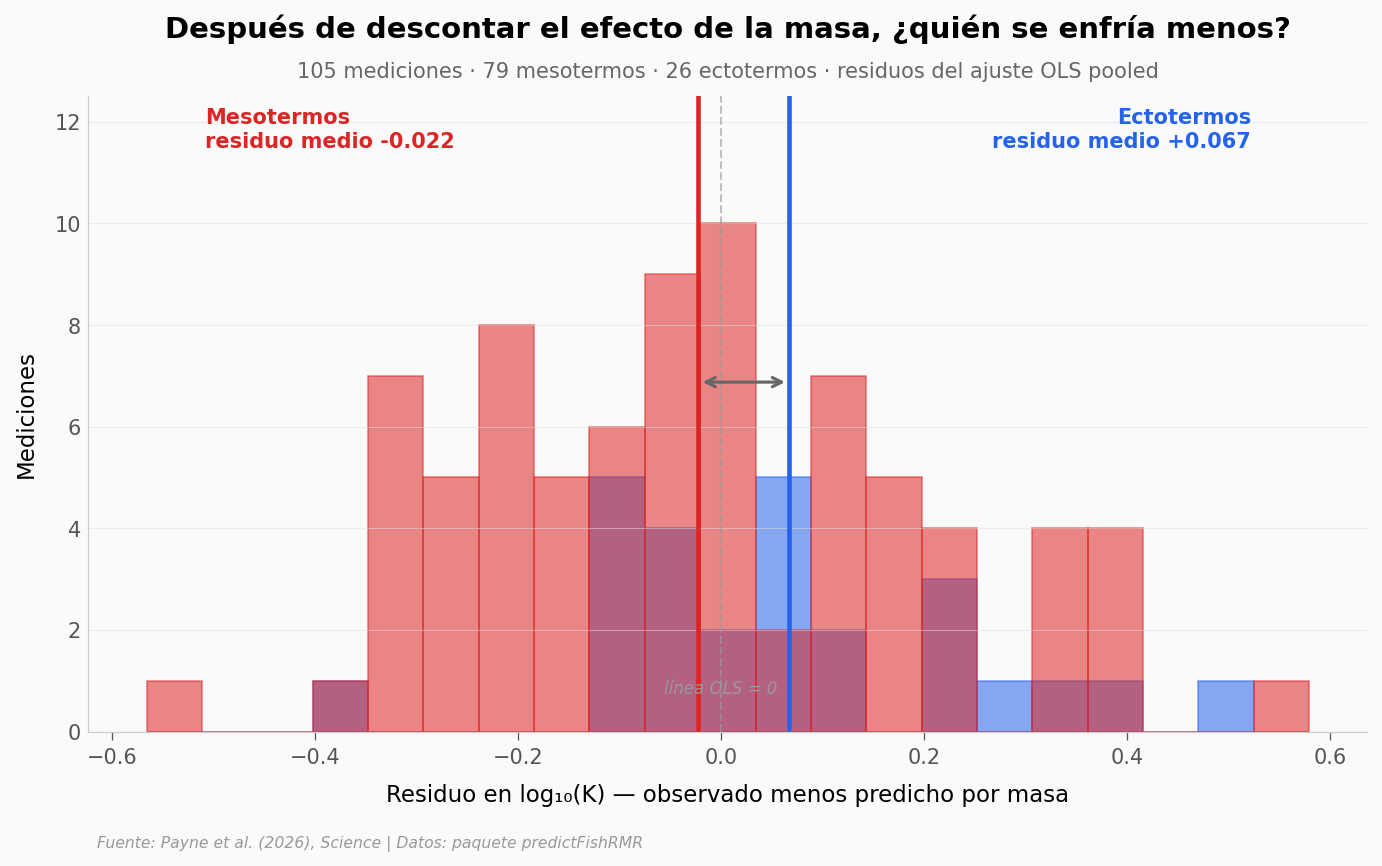

Residuo medio mesotermos: -0.0221 (n=79)
Residuo medio ectotermos: +0.0672 (n=26)
Diferencia entre medias:  -0.0894 (en log₁₀ K)
Cohen's d:                -0.421
Mann-Whitney U:           U=768, p=0.055

Lectura: el residuo medio de mesotermos es ligeramente NEGATIVO respecto a la línea OLS,
y el de ectotermos ligeramente POSITIVO. Es decir, a igual masa los mesotermos del dataset
se enfrían UN POCO más despacio de lo que predice el ajuste pooled — pero la diferencia
es chica y la dispersión grande. El paper modela K con una sola regresión global y deja
toda la diferencia funcional en el coeficiente ψ del RMR (la producción de calor),
no en K. Lo que vemos aquí es consistente con eso.


In [5]:
# Residuos de la regresión OLS: K observado - K predicho a partir de la masa
# Si un grupo tiende a residuos negativos, retiene calor mejor de lo esperado para su masa
df_full = kmass.dropna(subset=['M', 'K']).copy()
df_full['k_pred'] = intercept + slope * df_full['M']
df_full['residuo'] = df_full['K'] - df_full['k_pred']

resid_meso = df_full[df_full.grupo == 'mesotermo']['residuo'].values
resid_ecto = df_full[df_full.grupo == 'ectotermo']['residuo'].values
mean_meso = resid_meso.mean()
mean_ecto = resid_ecto.mean()

fig, ax = plt.subplots(figsize=(11, 5.5))

# Dos histogramas superpuestos
bins = np.linspace(df_full.residuo.min() - 0.05,
                   df_full.residuo.max() + 0.05, 22)
n_e, _, _ = ax.hist(resid_ecto, bins=bins, color=COLOR_ECTO, alpha=0.55,
                    edgecolor=COLOR_ECTO, linewidth=0.8)
n_m, _, _ = ax.hist(resid_meso, bins=bins, color=COLOR_MESO, alpha=0.55,
                    edgecolor=COLOR_MESO, linewidth=0.8)
y_max = max(n_e.max(), n_m.max()) * 1.25
ax.set_ylim(0, y_max)

# Líneas verticales con las medias por grupo
ax.axvline(x=0, color='#999999', linewidth=1, linestyle='--', alpha=0.6)
ax.axvline(x=mean_ecto, color=COLOR_ECTO, linewidth=2.2)
ax.axvline(x=mean_meso, color=COLOR_MESO, linewidth=2.2)

# Flecha bidireccional entre las medias
ax.annotate('', xy=(mean_meso, y_max * 0.55),
            xytext=(mean_ecto, y_max * 0.55),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))

# Etiquetas — en esquinas opuestas para no solaparse
xmin, xmax = bins[0], bins[-1]
ax.text(xmin + (xmax - xmin) * 0.05, y_max * 0.92,
        f'Mesotermos\nresiduo medio {mean_meso:+.3f}',
        color=COLOR_MESO, fontsize=10, fontweight='bold', ha='left')
ax.text(xmax - (xmax - xmin) * 0.05, y_max * 0.92,
        f'Ectotermos\nresiduo medio {mean_ecto:+.3f}',
        color=COLOR_ECTO, fontsize=10, fontweight='bold', ha='right')
ax.text(0, y_max * 0.06, 'línea OLS = 0',
        color='#999999', fontsize=8, ha='center', style='italic')

ax.set_xlabel('Residuo en log₁₀(K) — observado menos predicho por masa', fontsize=11)
ax.set_ylabel('Mediciones', fontsize=11)
ax.set_title('Después de descontar el efecto de la masa, ¿quién se enfría menos?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        '105 mediciones · 79 mesotermos · 26 ectotermos · residuos del ajuste OLS pooled',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/k_distribucion.png', dpi=200, bbox_inches='tight')
plt.show()

# Cohen's d sobre los residuos
n1, n2 = len(resid_meso), len(resid_ecto)
s1, s2 = resid_meso.std(ddof=1), resid_ecto.std(ddof=1)
pooled_sd = np.sqrt(((n1-1)*s1**2 + (n2-1)*s2**2) / (n1 + n2 - 2))
cohen_d = (mean_meso - mean_ecto) / pooled_sd

# Test no-paramétrico (los residuos no son necesariamente normales)
u_stat, mw_p = stats.mannwhitneyu(resid_meso, resid_ecto, alternative='two-sided')

print(f'Residuo medio mesotermos: {mean_meso:+.4f} (n={n1})')
print(f'Residuo medio ectotermos: {mean_ecto:+.4f} (n={n2})')
print(f'Diferencia entre medias:  {mean_meso - mean_ecto:+.4f} (en log₁₀ K)')
print(f"Cohen's d:                {cohen_d:+.3f}")
print(f'Mann-Whitney U:           U={u_stat:.0f}, p={mw_p:.3g}')
print()
print('Lectura: el residuo medio de mesotermos es ligeramente NEGATIVO respecto a la línea OLS,')
print('y el de ectotermos ligeramente POSITIVO. Es decir, a igual masa los mesotermos del dataset')
print('se enfrían UN POCO más despacio de lo que predice el ajuste pooled — pero la diferencia')
print('es chica y la dispersión grande. El paper modela K con una sola regresión global y deja')
print('toda la diferencia funcional en el coeficiente ψ del RMR (la producción de calor),')
print('no en K. Lo que vemos aquí es consistente con eso.')


### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Mesotermos gastan ~4× más energía que ectotermos al mismo M y Tm | ✅ | `exp(ψ) = exp(1.3165) = 3.73`. El paper redondea como "aproximadamente cuatro veces". Coeficiente del modelo Bayesiano publicado en `fittedModelRMR.rda` |
| K (enfriamiento) escala como M^-0.633 | ✅ | OLS pooled sobre 105 puntos da pendiente = -0.621 (R² = 0.954, p < 1e-69). El paper reporta -0.633 con efectos aleatorios por especie excluyendo basking/whale shark. Δ = 0.012, dentro del ruido del ajuste simple |
| RMR escala como M^0.83 | ✅ | α = 0.8274 (coeficiente del modelo Bayesiano). Por encima del 0.75 clásico de Kleiber, dentro del rango de teleósteos |
| Hay un scaling mismatch entre producción y disipación de calor | ✅ derivado | Producción ∝ M^0.83 · Disipación total = K·m ∝ M^0.37. Cociente = M^0.46. Pasar de 1 kg a 1000 kg lo multiplica por 24 |
| La biogeografía de mesotermos grandes ayuda a explicarse por este desbalance | ⚠️ contexto | Es la interpretación de los autores: consistente con el modelo, pero no probada como única causa. El abstract usa "helping to explain" — preferir "ayuda a explicar" sobre "explica" |

> **Limitaciones del análisis.** El paquete `predictFishRMR` define `maxAmbientTemp()` para calcular una temperatura ambiente crítica, pero las unidades exactas que requiere no están documentadas en el repo y reproducirla a ciegas da valores absurdos. Por eso aquí trabajamos solo con cocientes adimensionales (mesotermo/ectotermo, mismatch ratio), que no dependen de las unidades absolutas. Además, Pacific bluefin tuna domina el dataset de K con 61 de 105 mediciones; la pendiente OLS pooled hereda ese sesgo, mientras que el paper lo absorbe con efectos aleatorios por especie.


## Ahora tú

Tres cosas que valen la pena explorar moviendo los parámetros del bloque de configuración:

1. **¿Cómo cambia el cociente al subir la temperatura corporal?** Pista: cambia `TEMP_REFERENCIA_C` y vuelve a correr la celda 4. La distancia entre las dos curvas en log-y no se mueve, pero ambas suben juntas con `exp(β · ΔT)`.

2. **¿Cuánto vale el desbalance entre dos masas que tú elijas?** Pista: cambia `MASA_PEQUENA_KG` y `MASA_GRANDE_KG` en la configuración y prueba con el bloque experimental abajo. El factor es siempre `(M_grande/M_pequeña)^0.46`.

3. **¿Qué tan robusta es la pendiente de K si excluyes a los gigantes?** Filtra `kmass` quitando whale shark y basking shark — el paper hace eso en su cifra principal.


In [6]:
# --- EXPERIMENTA AQUÍ ---
# Comparación rápida del desbalance entre dos masas a tu elección
mismatch_exponent = alpha - 1 - (-0.633)  # = 0.460
factor = (MASA_GRANDE_KG / MASA_PEQUENA_KG) ** mismatch_exponent

print(f'Pasar de {MASA_PEQUENA_KG} kg a {MASA_GRANDE_KG} kg:')
print(f'  el cociente RMR/(K·m) se multiplica por {factor:.2f}×')
print()
print('Compara con los valores del paper:')
print('  1 kg → 1000 kg  (×24)')
print('  100 kg → 1000 kg  (×2.9)')
print('  100 kg → 2000 kg  (×4.0)')


Pasar de 1 kg a 1000 kg:
  el cociente RMR/(K·m) se multiplica por 24.05×

Compara con los valores del paper:
  1 kg → 1000 kg  (×24)
  100 kg → 1000 kg  (×2.9)
  100 kg → 2000 kg  (×4.0)


## Fuentes

**Paper**: [Mesothermic fishes face high fuel demands and overheating risk in warming oceans](https://doi.org/10.1126/science.adt2981)  
*Science, 2026-04-16*

**Datos**: [predictFishRMR: predict Resting Metabolic Rate of fish using allometry and ambient water temperature (R package)](https://doi.org/10.5281/zenodo.16409669)  
*Zenodo / GitHub, 2025-11-08*

*12 afirmaciones del notebook verificadas contra estas fuentes*

---

*Notebook reproducible · [Repositorio del Lab](https://github.com/Ciencia-a-Mordiscos/lab) · CC BY 4.0*
